**IMPLEMENTING OPTIMIZERS BY HAND**

In [ ]:
import torch
import matplotlib.pyplot as plt


In [ ]:
number_of_classes = 5
number_of_features = 2
samples_per_class = 2000
centroids = torch.tensor([[3.0, 10], [4.5, -3], [8.09, 0], [-20,4], [0.01, 4]])

In [ ]:
x_data = []
y_data = []
for class_id in range(number_of_classes):
  x = centroids[class_id] + 0.95 * torch.randn(samples_per_class, number_of_features)
  y = torch.full((samples_per_class,1), class_id)
  x_data.append(x)
  y_data.append(y)

x = torch.cat(x_data, dim=0)
y = torch.cat(y_data, dim=0)

In [ ]:
perm = torch.randperm(x.shape[0])
x = x[perm]
y = y[perm]

In [ ]:
x[0]

tensor([ 7.9331, -0.9498])

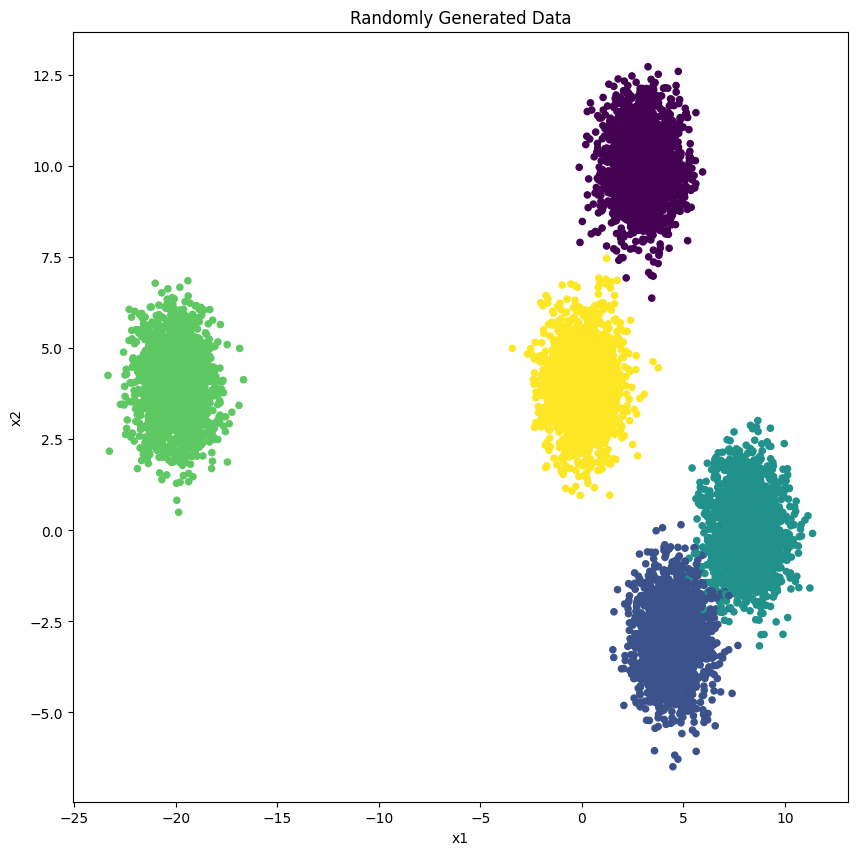

In [ ]:
plt.figure(figsize=(10,10))
plt.scatter(x[:,0], x[:,1], c=y, s=20)
plt.title("Randomly Generated Data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [262]:
import torch

class NeuralNetwork:
    def __init__(self, number_of_features, number_of_classes, learning_rate=1e-3):
        self.input_size = number_of_features
        self.output_layer = number_of_classes
        self.lr = learning_rate

        self.first_hidden_layer_size = 10
        self.second_hidden_layer_size = 10
        self.third_hidden_layer_size = 10

        self.parameters = {
            "w1": torch.randn(number_of_features, self.first_hidden_layer_size) * 0.05,
            "b1": torch.zeros(self.first_hidden_layer_size),

            "w2": torch.randn(self.first_hidden_layer_size, self.second_hidden_layer_size) * 0.05,
            "b2": torch.zeros(self.second_hidden_layer_size),

            "w3": torch.randn(self.second_hidden_layer_size, self.third_hidden_layer_size) * 0.05,
            "b3": torch.zeros(self.third_hidden_layer_size),

            "wO": torch.randn(self.third_hidden_layer_size, self.output_layer) * 0.05,
            "bO": torch.zeros(self.output_layer),
        }

        self.cache = {}
        self.grads = {k: torch.zeros_like(v) for k, v in self.parameters.items()}

    def _ReLu(self, x):
        return x.clamp(min=0)

    def _softmax(self, logits):
        # stable softmax (we still use probs for backward seed)
        shifted = logits - logits.max(dim=1, keepdim=True).values
        exp_logits = torch.exp(shifted)
        probs = exp_logits / exp_logits.sum(dim=1, keepdim=True)
        # clamp to avoid exact 0s feeding backward in extreme cases
        return probs.clamp(min=1e-9, max=1.0)

    @staticmethod
    def cross_entropy_from_logits(logits, y):
        """
        Numerically-stable cross entropy computed from logits.
        Equivalent to: -log_softmax(logits)[range(N), y].mean()
        """
        shifted = logits - logits.max(dim=1, keepdim=True).values
        logsumexp = torch.log(torch.exp(shifted).sum(dim=1, keepdim=True))
        log_probs = shifted - logsumexp
        return -log_probs[torch.arange(logits.shape[0]), y].mean()

    def _one_hot_encode(self, y, num_classes, device=None, dtype=None):
        N = y.shape[0]
        device = device if device is not None else y.device
        dtype = dtype if dtype is not None else torch.float32
        Y = torch.zeros((N, num_classes), device=device, dtype=dtype)
        Y[torch.arange(N, device=device), y] = 1
        return Y

    def _forward(self, x, return_logits=False):
        self.cache["x"] = x

        z1 = x @ self.parameters["w1"] + self.parameters["b1"]
        a1 = self._ReLu(z1)

        z2 = a1 @ self.parameters["w2"] + self.parameters["b2"]
        a2 = self._ReLu(z2)

        z3 = a2 @ self.parameters["w3"] + self.parameters["b3"]
        a3 = self._ReLu(z3)

        zO = a3 @ self.parameters["wO"] + self.parameters["bO"]   # logits
        probs = self._softmax(zO)

        self.cache.update({
            "z1": z1, "a1": a1,
            "z2": z2, "a2": a2,
            "z3": z3, "a3": a3,
            "zO": zO, "probs": probs,
        })

        return (probs, zO) if return_logits else probs

    def predict(self, x):
        probs = self._forward(x, return_logits=False)
        return probs.argmax(dim=1)

    def backward(self, probs, y):
        # clear grads each step
        for k in self.grads:
            self.grads[k].zero_()

        x  = self.cache["x"]
        z1 = self.cache["z1"]; a1 = self.cache["a1"]
        z2 = self.cache["z2"]; a2 = self.cache["a2"]
        z3 = self.cache["z3"]; a3 = self.cache["a3"]

        w2 = self.parameters["w2"]
        w3 = self.parameters["w3"]
        wO = self.parameters["wO"]

        N = x.shape[0]
        Y = self._one_hot_encode(
            y=y,
            num_classes=probs.shape[1],
            device=probs.device,
            dtype=probs.dtype
        )

        # seed gradient (softmax + cross-entropy)
        dZ_O = (probs - Y) / N

        # Output layer
        self.grads["wO"] = a3.T @ dZ_O
        self.grads["bO"] = dZ_O.sum(dim=0)

        # Layer 3
        dA3 = dZ_O @ wO.T
        dZ3 = dA3.clone()
        dZ3[z3 <= 0] = 0

        self.grads["w3"] = a2.T @ dZ3
        self.grads["b3"] = dZ3.sum(dim=0)

        # Layer 2
        dA2 = dZ3 @ w3.T
        dZ2 = dA2.clone()
        dZ2[z2 <= 0] = 0

        self.grads["w2"] = a1.T @ dZ2
        self.grads["b2"] = dZ2.sum(dim=0)

        # Layer 1
        dA1 = dZ2 @ w2.T
        dZ1 = dA1.clone()
        dZ1[z1 <= 0] = 0

        self.grads["w1"] = x.T @ dZ1
        self.grads["b1"] = dZ1.sum(dim=0)

        # SGD update
        with torch.no_grad():
            for p in self.parameters:
                self.parameters[p] -= self.lr * self.grads[p]




In [277]:
model = NeuralNetwork(
    number_of_features=number_of_features,
    number_of_classes=number_of_classes,
    learning_rate=0.003
)

In [278]:
sgd = []

In [279]:
full_batch = []

In [280]:
def train(model, x, y, save_loss_to, epochs=100, batch_size=32, SGD=True):

    N = x.shape[0]


    for epoch in range(epochs):

        if SGD:
            perm = torch.randperm(N)
            x_shuffled = x[perm]
            y_shuffled = y[perm]

            epoch_loss = 0.0
            num_batches = 0

            for i in range(0, N, batch_size):
                xb = x_shuffled[i:i+batch_size]
                yb = y_shuffled[i:i+batch_size]

                probs, logits = model._forward(xb, return_logits=True)
                loss = model.cross_entropy_from_logits(logits, yb)
                model.backward(probs, yb)

                epoch_loss += loss.item()
                num_batches += 1

            avg_loss = epoch_loss / max(1, num_batches)
            save_loss_to.append(avg_loss)

        else:
            probs, logits = model._forward(x, return_logits=True)
            loss = model.cross_entropy_from_logits(logits, y)
            model.backward(probs, y)

            save_loss_to.append(loss.item())

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Loss: {save_loss_to[-1]:.4f}")



In [281]:
train(model, x, y, full_batch, epochs=100, batch_size=32, SGD=True)

Epoch 0 | Loss: 1.6095
Epoch 10 | Loss: nan
Epoch 20 | Loss: nan
Epoch 30 | Loss: nan


KeyboardInterrupt: 

In [ ]:
plt.plot(sgd)
plt.plot(full_batch)
plt.legend(["SGD", "Full Batch"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()